In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../03_app/data/Schadstoff_Wetter.csv")

if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.set_index("timestamp", inplace=True)
elif "datum" in df.columns and "stunde" in df.columns:
    df["timestamp"] = pd.to_datetime(df["datum"]) + pd.to_timedelta(df["stunde"], unit="h")
    df.set_index("timestamp", inplace=True)

print(f"{len(df):,} Zeilen von {df.index.min().date()} bis {df.index.max().date()}")

394,488 Zeilen von 1980-01-01 bis 2024-12-31


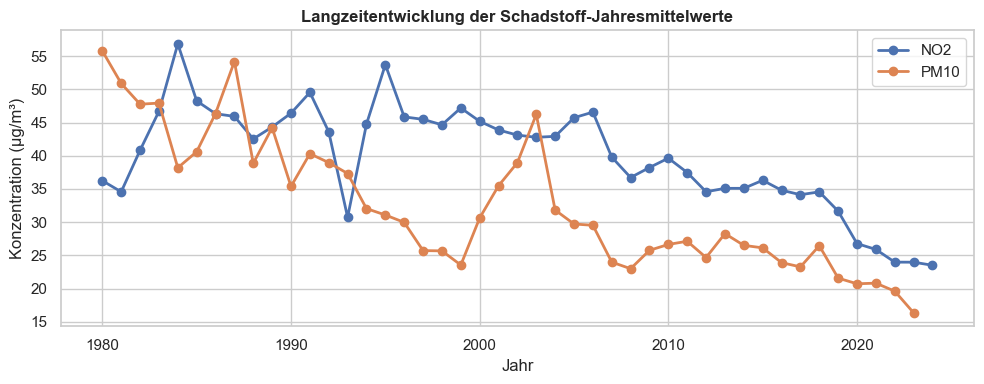

In [2]:
schadstoffe = ["no2", "pm10"]   # zum Anpassen: ["no2", "pm10", "o3"]

df_yearly = df[schadstoffe].resample("YE").mean()
df_yearly.index = df_yearly.index.year

fig, ax = plt.subplots(figsize=(10, 4))
for col in schadstoffe:
    ax.plot(df_yearly.index, df_yearly[col], marker="o", linewidth=2, label=col.upper())
ax.set_title("Langzeitentwicklung der Schadstoff-Jahresmittelwerte",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Jahr")
ax.set_ylabel("Konzentration (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

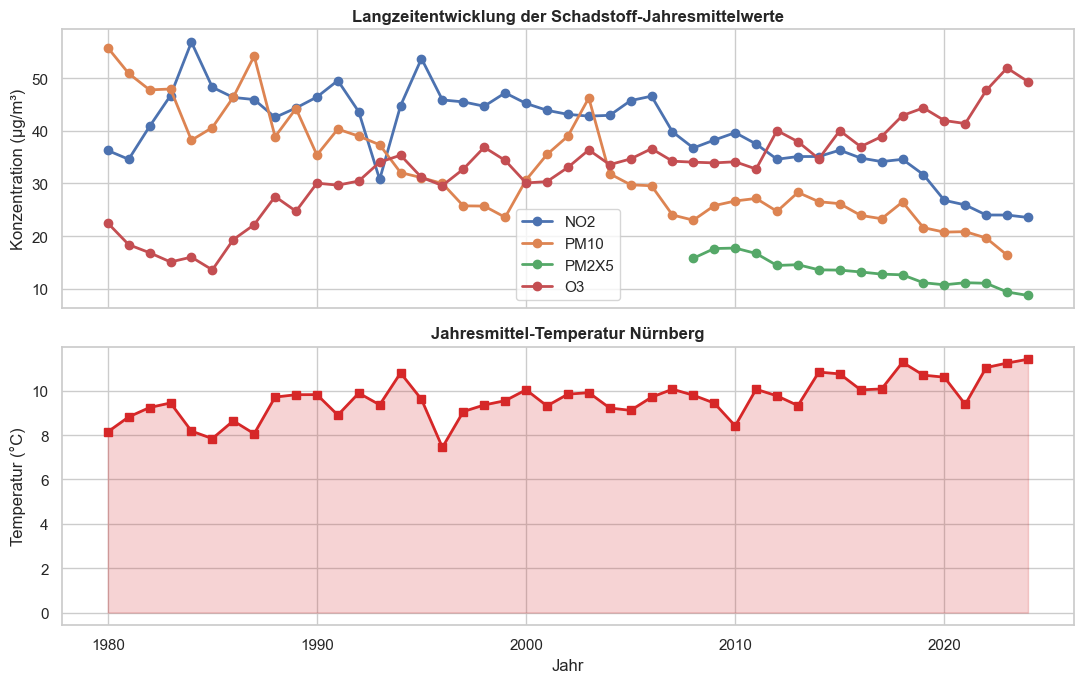

In [4]:
schadstoffe = ["no2", "pm10", "pm2x5", "o3"]

df_yearly_schad = df[schadstoffe].resample("YE").mean()
df_yearly_temp = df["temperatur"].resample("YE").mean()
df_yearly_schad.index = df_yearly_schad.index.year
df_yearly_temp.index = df_yearly_temp.index.year

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Oben: Schadstoffe
for col in schadstoffe:
    ax1.plot(df_yearly_schad.index, df_yearly_schad[col],
             marker="o", linewidth=2, label=col.upper())
ax1.set_ylabel("Konzentration (µg/m³)")
ax1.set_title("Langzeitentwicklung der Schadstoff-Jahresmittelwerte",
              fontsize=12, fontweight="bold")
ax1.legend()

# Unten: Temperatur
ax2.plot(df_yearly_temp.index, df_yearly_temp.values,
         marker="s", linewidth=2, color="tab:red")
ax2.fill_between(df_yearly_temp.index, df_yearly_temp.values,
                 alpha=0.2, color="tab:red")
ax2.set_xlabel("Jahr")
ax2.set_ylabel("Temperatur (°C)")
ax2.set_title("Jahresmittel-Temperatur Nürnberg",
              fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()